## All the imports

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from feature.selector import Selective, SelectionMethod
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
import shap
from lime.lime_tabular import LimeTabularExplainer
from itertools import cycle

## Preparing the data

In [3]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("12 features - MI dataset.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)
# print(df_num.shape)
# print(df_num.columns)
# print(df_num['MHW_count'].value_counts())

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_count'] = df_numeric['mhw_count'].astype(str)

df_numeric.loc[df_numeric['mhw_count'].isin(['2', '3']), 'mhw_count'] = '2+'


print(df_numeric['mhw_count'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y = shuffled_df_numeric['mhw_count']
X.shape, y.shape

mhw_count
0     3245
1      663
2+     158
Name: count, dtype: int64


((4066, 11), (4066,))

cross validation scores: [0.97420147 0.98277983 0.97662977 0.95694957 0.97539975]
0.9732 accuracy with a standard deviation of 0.0086
Accuracy: 97.05%
[[638  11   1]
 [ 10 122   1]
 [  1   0  30]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       650
           1       0.92      0.92      0.92       133
          2+       0.94      0.97      0.95        31

    accuracy                           0.97       814
   macro avg       0.95      0.96      0.95       814
weighted avg       0.97      0.97      0.97       814



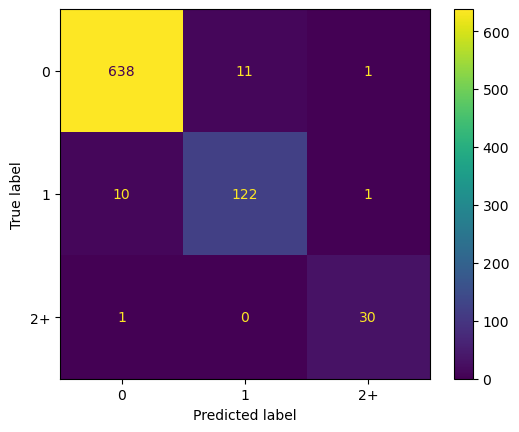

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.2, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = RandomForestClassifier(class_weight = 'balanced', random_state=0)
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp_3 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

## Random forest classifier with 11 features

In [5]:
forest.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

## Gridsearch 

In [10]:
param_grid = [
     {'n_estimators': [50, 100, 200, 500],
    'min_samples_split': [2, 10, 50, 100],
     'min_samples_leaf': [1, 5, 10, 50],
     'max_features': [None, 'log2', 'sqrt'],
    'class_weight': ['balanced', 'balanced_subsample'],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20]
}]

grid = GridSearchCV(forest, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
sorted(model_grid.cv_results_.keys())

Fitting 5 folds for each of 3072 candidates, totalling 15360 fits
[CV 1/5] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=0.994, test=0.975) total time=   0.3s
[CV 2/5] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=0.993, test=0.968) total time=   0.2s
[CV 3/5] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=0.994, test=0.969) total time=   0.2s
[CV 4/5] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=0.994, test=0.969) total time=   0.2s
[CV 5/5] END class_weight=balanced, criterion=gini, max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, 

['mean_fit_time',
 'mean_score_time',
 'mean_test_score',
 'mean_train_score',
 'param_class_weight',
 'param_criterion',
 'param_max_depth',
 'param_max_features',
 'param_min_samples_leaf',
 'param_min_samples_split',
 'param_n_estimators',
 'params',
 'rank_test_score',
 'split0_test_score',
 'split0_train_score',
 'split1_test_score',
 'split1_train_score',
 'split2_test_score',
 'split2_train_score',
 'split3_test_score',
 'split3_train_score',
 'split4_test_score',
 'split4_train_score',
 'std_fit_time',
 'std_score_time',
 'std_test_score',
 'std_train_score']

cross validation scores: [0.97420147 0.98400984 0.98154982 0.96063961 0.97785978]
0.9757 accuracy with a standard deviation of 0.0082
Accuracy: 97.30%
[[1281   14    4]
 [  25  240    0]
 [   1    0   62]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1299
           1       0.94      0.91      0.92       265
          2+       0.94      0.98      0.96        63

    accuracy                           0.97      1627
   macro avg       0.95      0.96      0.96      1627
weighted avg       0.97      0.97      0.97      1627



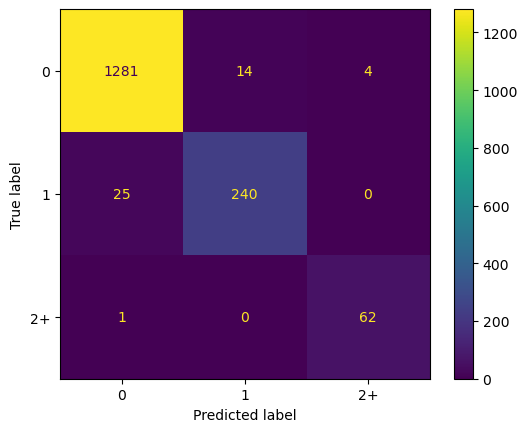

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.2, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = RandomForestClassifier(n_estimators = 1000, max_features = 'log2', class_weight = 'balanced', random_state=0)
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test)
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
#disp_2.plot()
print(classification_report(y_test, y_pred))


## Feature importance

<Axes: >

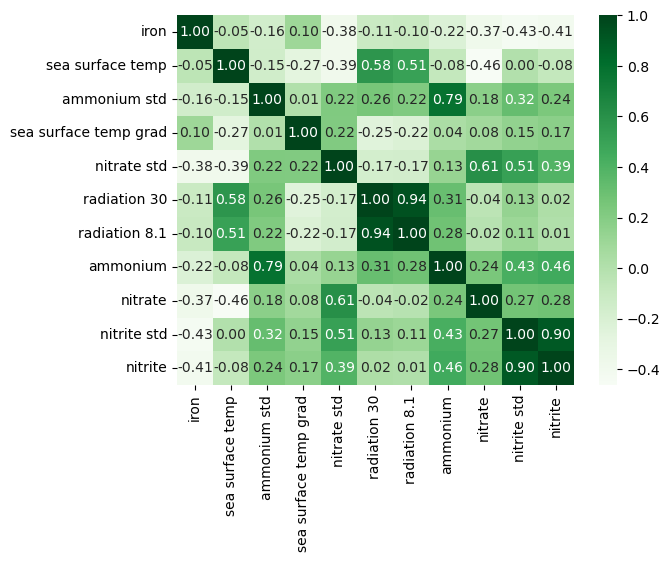

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get top N features
top_n = 12
top_features = feature_importance.head(top_n).index.tolist()

# 2. Filter dataset for top features
X_top = X[top_features]

# 3. Compute correlation matrix
correlation_matrix = X_top.corr()

#X = feature_importance.iloc[0:20]
#matrix = X.corr()

# plotting correlation matrix
sns.heatmap(correlation_matrix, cmap="Greens", annot=True, fmt=".2f")


In [19]:
feature_names = X.columns
feature_importance = pd.DataFrame(forest.feature_importances_, index = feature_names).sort_values(0, ascending=False)
feature_importance

,0
iron,0.161928
sea surface temp,0.097927
ammonium std,0.096235
sea surface temp grad,0.094615
nitrate std,0.086665
radiation 30,0.085895
radiation 8.1,0.082686
ammonium,0.080321
nitrate,0.074067
nitrite std,0.073751


<Axes: >

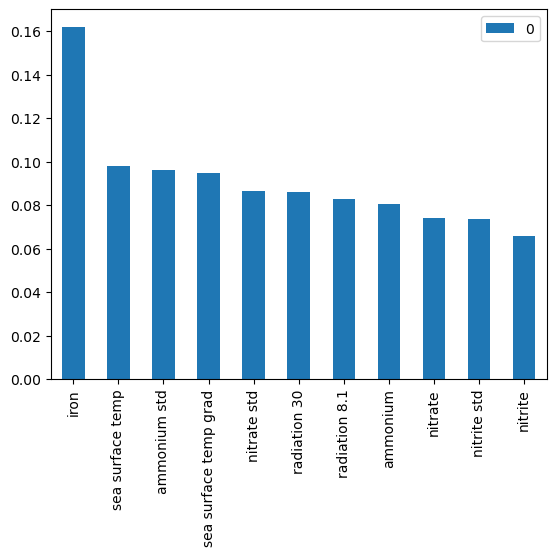

In [20]:
feature_importance.head(11).plot(kind='bar')

In [4]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("12 features - no imp.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)
# print(df_num.shape)
# print(df_num.columns)
# print(df_num['MHW_count'].value_counts())

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_count'] = df_numeric['mhw_count'].astype(str)

df_numeric.loc[df_numeric['mhw_count'].isin(['2', '3']), 'mhw_count'] = '2+'


print(df_numeric['mhw_count'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

shuffled_df_numeric = shuffled_df_numeric.rename({'sea surface temp':'SST', 'sea surface temp grad':'SST grad'}, axis = 1)

# Separate features (X) and labels (y) after shuffling
X_no = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y_no = shuffled_df_numeric['mhw_count']
X_no.shape, y_no.shape

mhw_count
0     3245
1      663
2+     158
Name: count, dtype: int64


((4066, 11), (4066,))

## Random forest with unimputed dataset (Best model)

cross validation scores: [0.97420147 0.98523985 0.97785978 0.95940959 0.97662977]
0.9747 accuracy with a standard deviation of 0.0085
Accuracy: 97.70%
[[960  12   2]
 [ 12 186   1]
 [  1   0  46]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       974
           1       0.94      0.93      0.94       199
          2+       0.94      0.98      0.96        47

    accuracy                           0.98      1220
   macro avg       0.95      0.97      0.96      1220
weighted avg       0.98      0.98      0.98      1220



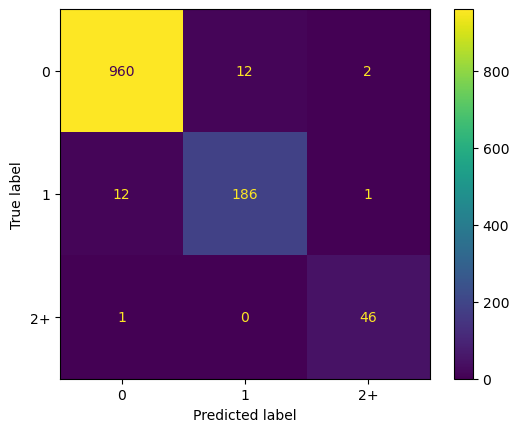

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_no, y_no, stratify = y_no, test_size=0.3, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = RandomForestClassifier(class_weight = 'balanced', random_state=0)
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X_no, y_no, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test)
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
#disp_2.plot()
print(classification_report(y_test, y_pred))

In [7]:
param_grid = [
     {'min_samples_split': [2, 10, 50],
     'min_samples_leaf': [1, 5, 10, 50],
     'max_features': [None, 'log2', 'sqrt'],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 20]
}]

grid = GridSearchCV(forest, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


the best score was 0.9753992673992675
the best parameters were {'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.810209,0.139383,0.011940,0.004565,balanced,gini,None,None,1,2,"{'class_weight': 'balanced', 'criterion': 'gin...",0.973886,0.970814,0.970769,0.963077,0.990769,0.973863,0.009176,21
1,0.713624,0.057706,0.012085,0.007889,balanced,gini,None,None,1,10,"{'class_weight': 'balanced', 'criterion': 'gin...",0.972350,0.964670,0.969231,0.961538,0.976923,0.968942,0.005449,79
2,0.741424,0.113603,0.005054,0.006495,balanced,gini,None,None,1,50,"{'class_weight': 'balanced', 'criterion': 'gin...",0.943164,0.935484,0.926154,0.927692,0.933846,0.933268,0.006081,257
3,0.755146,0.105076,0.006546,0.006088,balanced,gini,None,None,5,2,"{'class_weight': 'balanced', 'criterion': 'gin...",0.969278,0.966206,0.963077,0.950769,0.973846,0.964635,0.007792,101
4,0.757012,0.138419,0.011042,0.009416,balanced,gini,None,None,5,10,"{'class_weight': 'balanced', 'criterion': 'gin...",0.969278,0.966206,0.963077,0.950769,0.973846,0.964635,0.007792,101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,0.479943,0.107264,0.008305,0.007094,None,entropy,20,sqrt,10,10,"{'class_weight': None, 'criterion': 'entropy',...",0.966206,0.963134,0.950769,0.947692,0.969231,0.959406,0.008584,141
644,0.347037,0.015557,0.009578,0.007821,None,entropy,20,sqrt,10,50,"{'class_weight': None, 'criterion': 'entropy',...",0.941628,0.953917,0.927692,0.938462,0.949231,0.942186,0.009072,193
645,0.392115,0.061087,0.006893,0.006496,None,entropy,20,sqrt,50,2,"{'class_weight': None, 'criterion': 'entropy',...",0.880184,0.870968,0.873846,0.878462,0.884615,0.877615,0.004790,415
646,0.392025,0.082342,0.011467,0.006200,None,entropy,20,sqrt,50,10,"{'class_weight': None, 'criterion': 'entropy',...",0.880184,0.870968,0.873846,0.878462,0.884615,0.877615,0.004790,415


cross validation scores: [0.97420147 0.9803198  0.97908979 0.96063961 0.97416974]
0.9737 accuracy with a standard deviation of 0.0070
Accuracy: 97.67%
[[642   7   1]
 [ 10 122   1]
 [  0   0  31]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       650
           1       0.95      0.92      0.93       133
          2+       0.94      1.00      0.97        31

    accuracy                           0.98       814
   macro avg       0.96      0.97      0.96       814
weighted avg       0.98      0.98      0.98       814



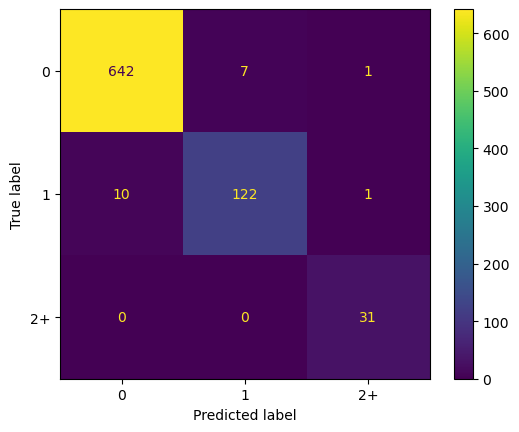

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_no, y_no, stratify = y_no, test_size=0.2, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

forest = RandomForestClassifier(criterion = 'entropy', class_weight = None, max_features = 'log2', random_state=0)
forest.fit(X_train, y_train)

cross_val_scores = cross_val_score(forest, X_no, y_no, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = forest.predict(X_test)
prob_pred = forest.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test)
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
#disp_2.plot()
print(classification_report(y_test, y_pred))

In [169]:
feature_names = X_no.columns
feature_importance = pd.DataFrame(forest.feature_importances_, index = feature_names).sort_values(0, ascending=False)
feature_importance

,0
iron,0.156074
SST,0.110115
ammonium std,0.099913
radiation 30,0.087458
SST grad,0.086711
nitrate,0.084481
nitrate std,0.084285
nitrite std,0.081686
radiation 8.1,0.079533
ammonium,0.070534


<Axes: >

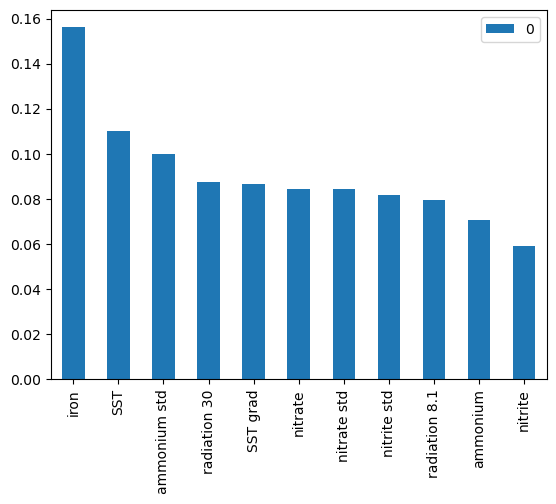

In [170]:
feature_importance.head(11).plot(kind='bar')

<Axes: >

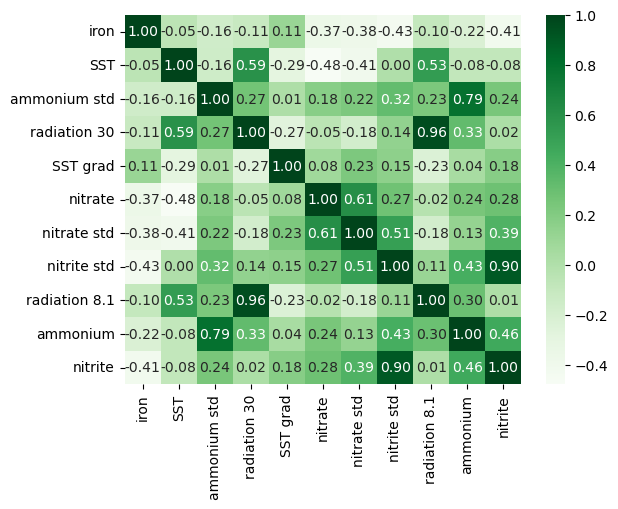

In [171]:
# 1. Get top N features
top_n = 11
top_features = feature_importance.head(top_n).index.tolist()

# 2. Filter dataset for top features
X_top = X_no[top_features]

# 3. Compute correlation matrix
correlation_matrix = X_top.corr()

#X = feature_importance.iloc[0:20]
#matrix = X.corr()

# plotting correlation matrix
sns.heatmap(correlation_matrix, cmap="Greens", annot=True, fmt=".2f")

## Lime

In [7]:
# Create the explainer
explainer = LimeTabularExplainer(X_no.values, 
                                   feature_names=X_no.columns, 
                                   class_names=['rings'], 
                                   mode='classification',
                                 kernel_width = 5,
                                 discretize_continuous = False,
                                 verbose = True,                                
                                   random_state=42)

In [8]:
constant_features = X_no.columns[X_no.std() == 0]
X = X_no.drop(columns=constant_features)
# Get explanation for first row
exp = explainer.explain_instance(X_no.iloc[0], 
                                 forest.predict, 
                                labels=X_no.columns
                                )

#Display explanation
exp.show_in_notebook(show_table=True)

exp.save_to_file('explanation_1.html')

C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


NotImplementedError: LIME does not currently support classifier models without probability scores. If this conflicts with your use case, please let us know: https://github.com/datascienceinc/lime/issues/16

## Shap values

In [9]:
# Visualize the SHAP values for the first prediction
shap.initjs()  # Initialize JS visualization

# Get shap values
explainer = shap.Explainer(forest)
shap_values = explainer(X_no)
print(np.shape(shap_values))


(4066, 11, 3)


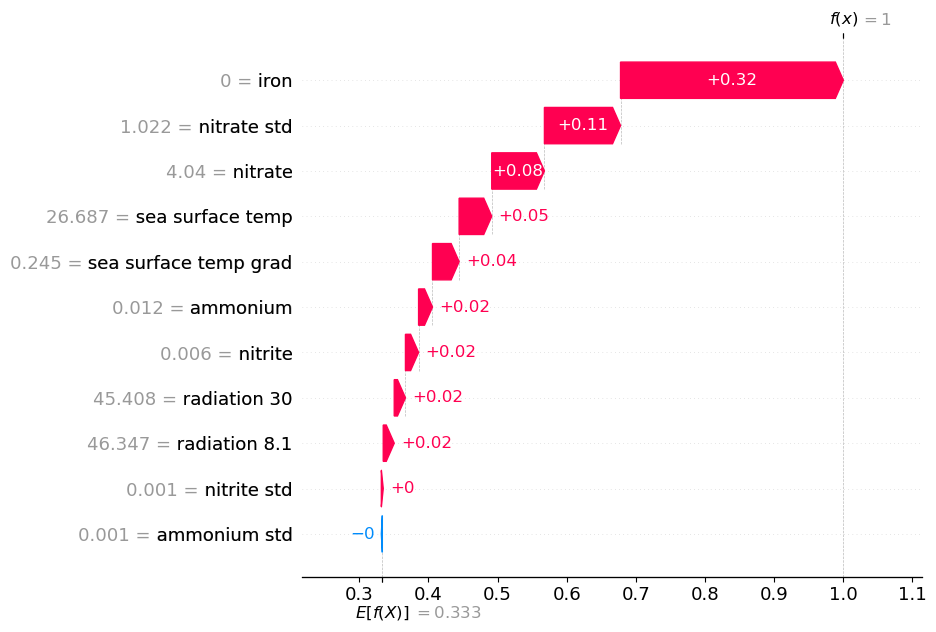

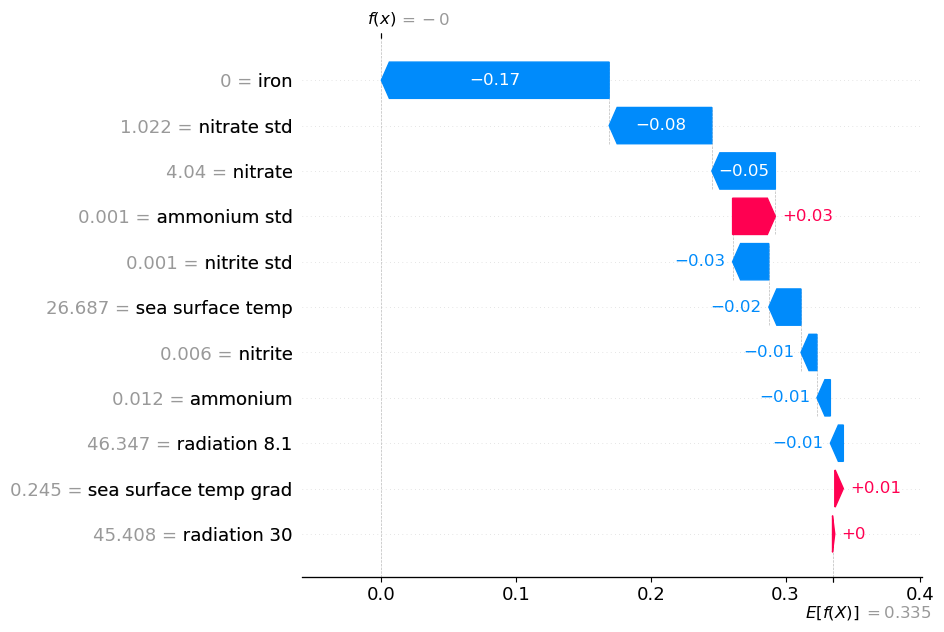

None


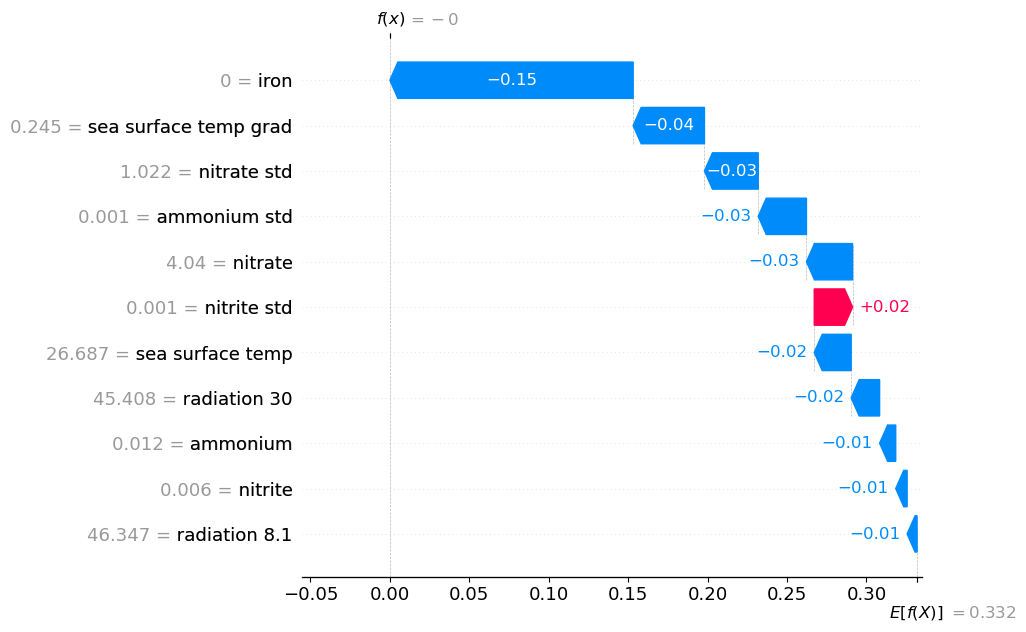

None


In [18]:
# Waterfall plot for first observation
shap.plots.waterfall(shap_values[0, :, 0], max_display = 11)
print(shap.plots.waterfall(shap_values[0, :, 1], max_display = 11))
print(shap.plots.waterfall(shap_values[0, :, 2], max_display = 11))

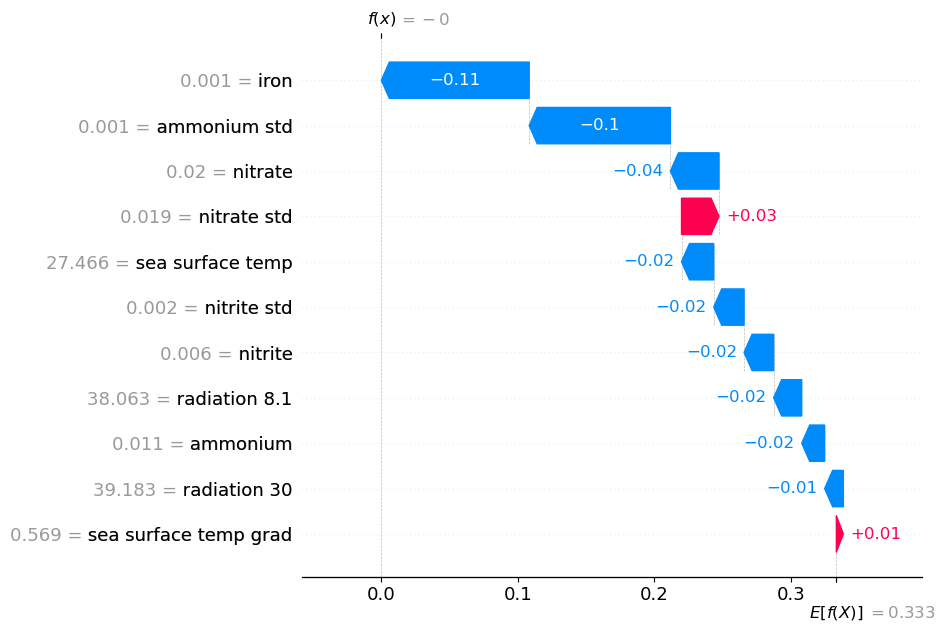

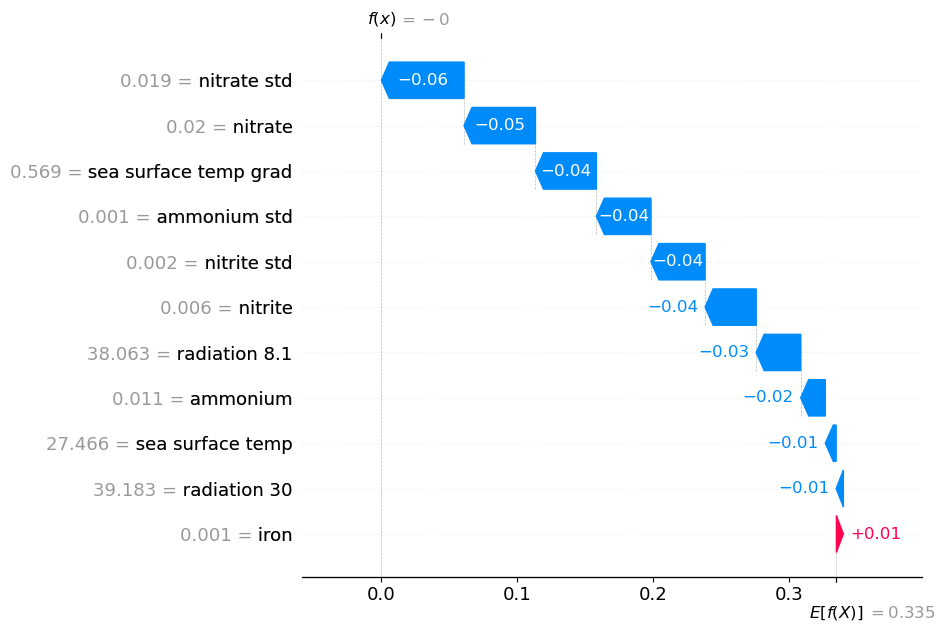

None


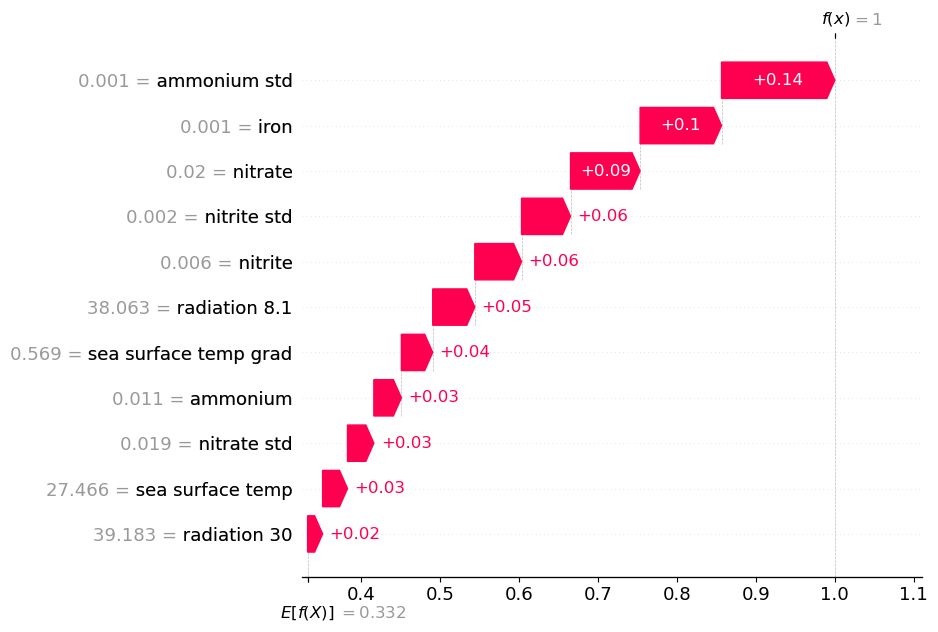

None


In [29]:
# Waterfall plot for first observation
shap.plots.waterfall(shap_values[9, :, 0], max_display = 11)
print(shap.plots.waterfall(shap_values[9, :, 1], max_display = 11))
print(shap.plots.waterfall(shap_values[9, :, 2], max_display = 11))

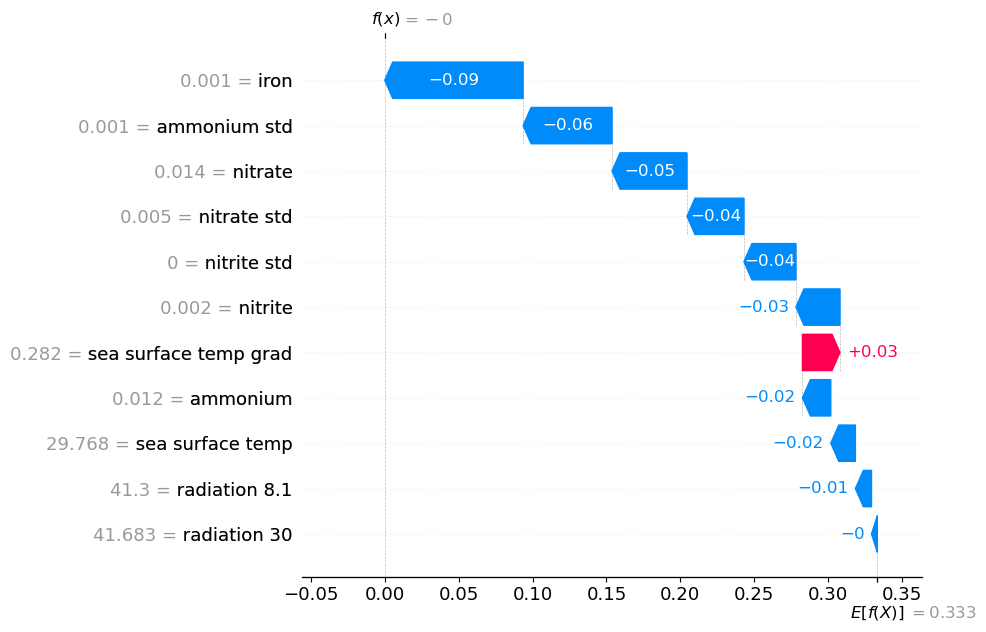

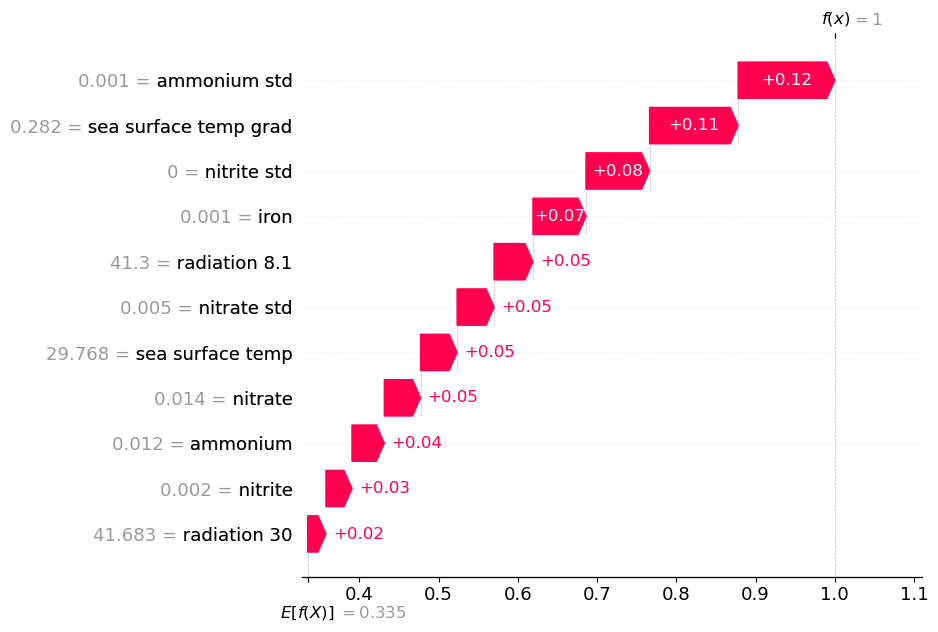

None


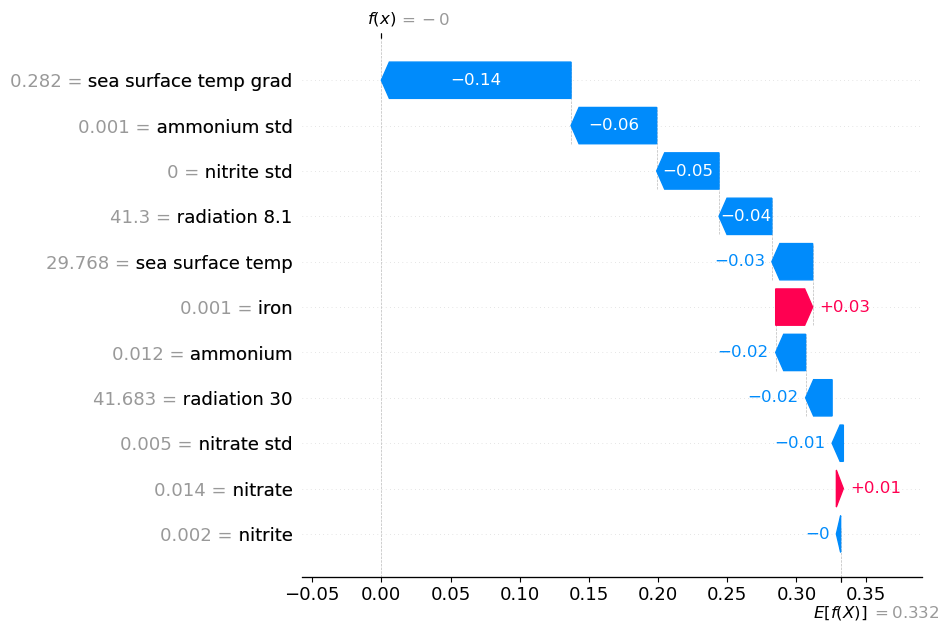

None


In [55]:
# Waterfall plot for first observation
shap.plots.waterfall(shap_values[32, :, 0], max_display = 11)
print(shap.plots.waterfall(shap_values[32, :, 1], max_display = 11))
print(shap.plots.waterfall(shap_values[32, :, 2], max_display = 11))

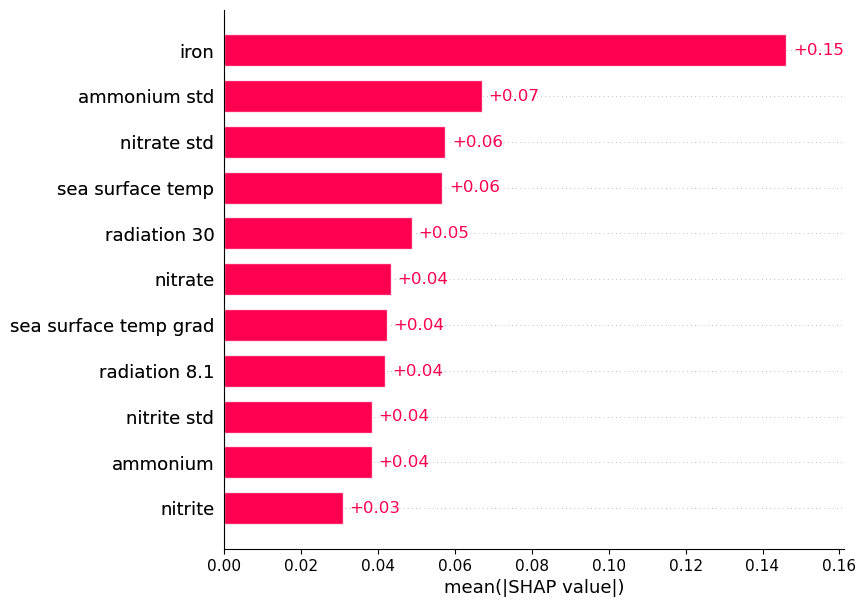

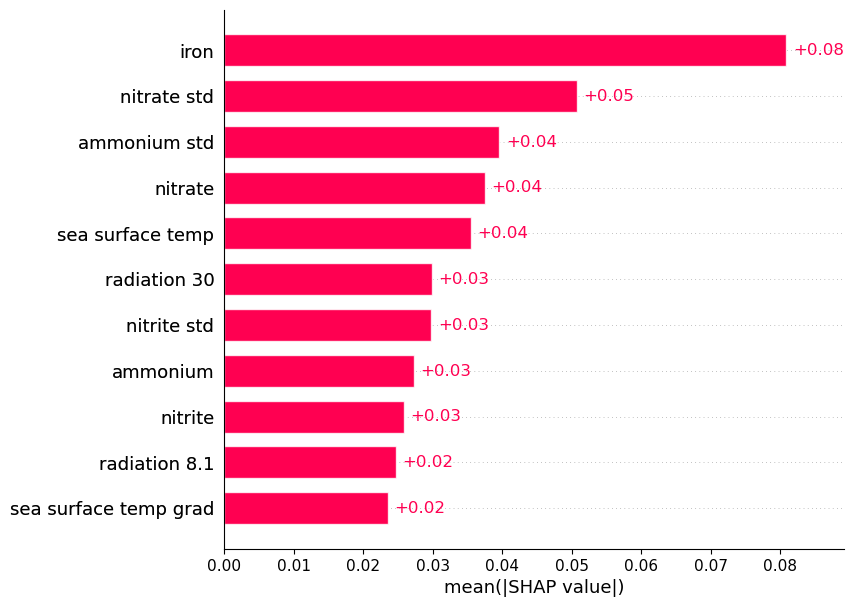

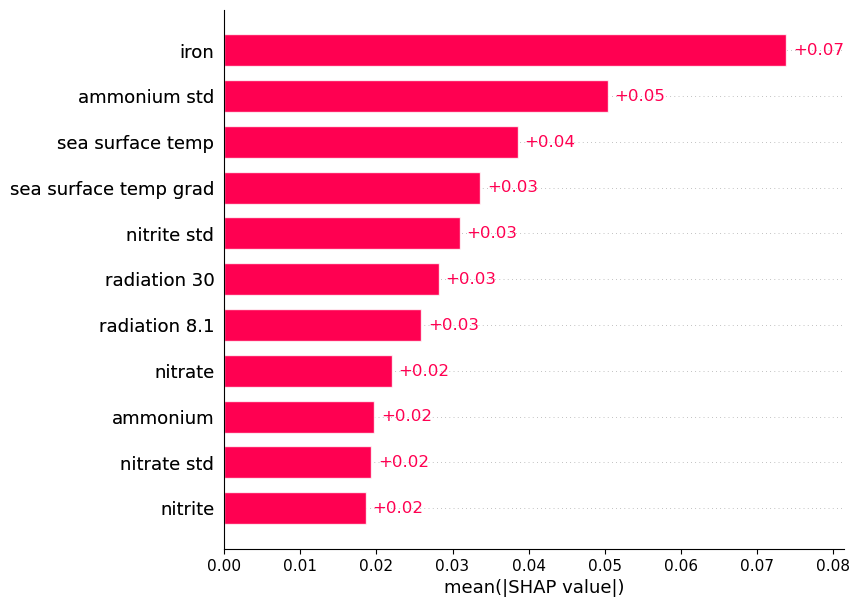

In [57]:
# Plot for a specific class (most commonly class 1)
shap.plots.bar(shap_values[..., 0], max_display = 11)  # Replace 1 with your target class
# Plot for a specific class (most commonly class 1)
shap.plots.bar(shap_values[..., 1], max_display = 11)  # Replace 1 with your target class
# Plot for a specific class (most commonly class 1)
shap.plots.bar(shap_values[..., 2], max_display = 11)  # Replace 1 with your target class

Amount of heatwaves 0 Beeswarm Plot


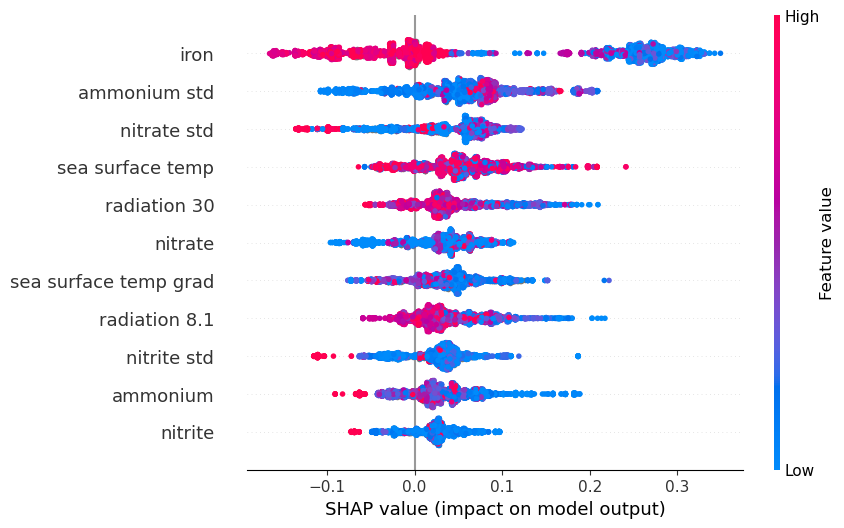

Amount of heatwaves 1 Beeswarm Plot


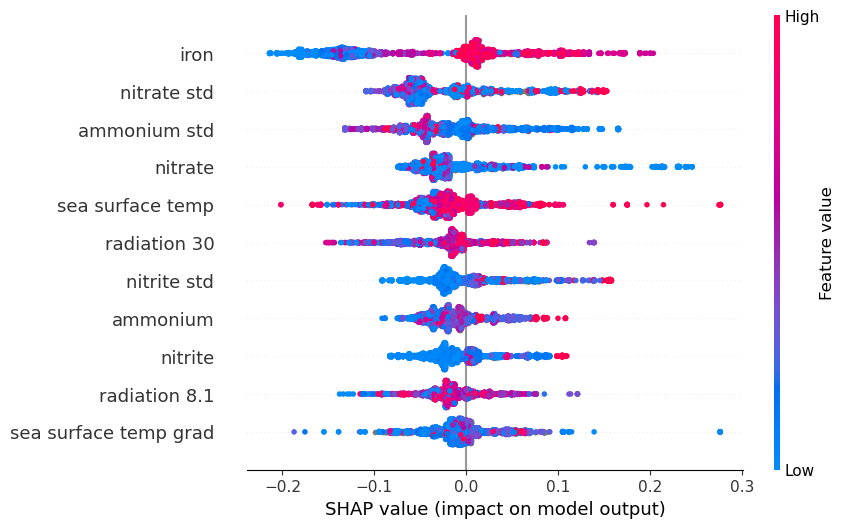

Amount of heatwaves 2 Beeswarm Plot


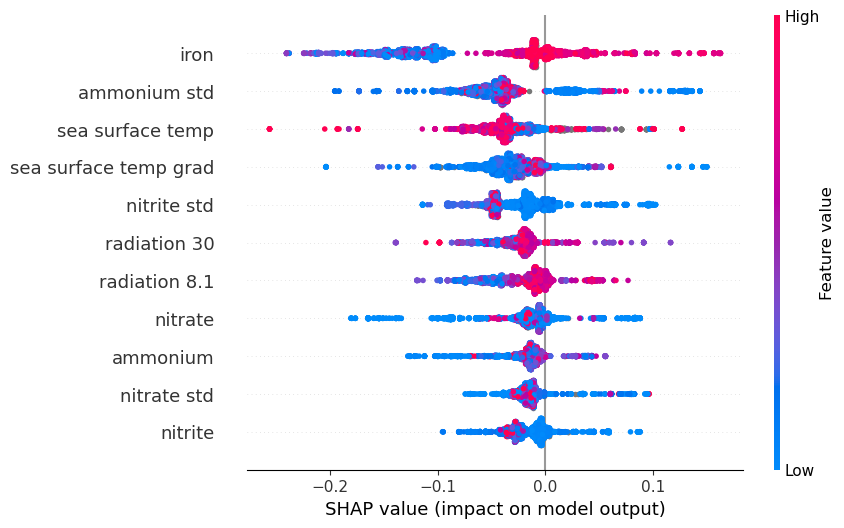

In [59]:
## Or for all classes separately
for i in range(shap_values.shape[2]):
    print(f"Amount of heatwaves {i} Beeswarm Plot")
    shap.plots.beeswarm(shap_values[..., i], max_display = 11)

In [69]:
print(df[df.duplicated])
df.nunique().sort_values()

      ammonium  ammonium std   nitrite  nitrite std   nitrate      iron  \
1     0.017782      0.003814  0.033199     0.021603  0.006594  0.001293   
4     0.019621      0.001549  0.049836     0.016420  0.008997  0.001387   
10    0.022870      0.002393  0.044259     0.014981  0.008068  0.001388   
11    0.022870      0.002393  0.044259     0.014981  0.008068  0.001388   
12    0.022870      0.002393  0.044259     0.014981  0.008068  0.001388   
...        ...           ...       ...          ...       ...       ...   
4047  0.035179      0.003054  0.348002     0.032939  2.061668  0.000209   
4048  0.035179      0.003054  0.348002     0.032939  2.061668  0.000209   
4049  0.035179      0.003054  0.348002     0.032939  2.061668  0.000209   
4050  0.035179      0.003054  0.348002     0.032939  2.061668  0.000209   
4053  0.035179      0.003054  0.348002     0.032939  2.061668  0.000209   

      nitrate std  radiation 8.1  radiation 30  sea surface temp grad  \
1        0.002778      32.

mhw_count                  4
iron                     197
ammonium                 202
ammonium std             202
nitrite                  202
nitrite std              202
nitrate                  202
nitrate std              202
sea surface temp grad    519
radiation 30             761
radiation 8.1            773
sea surface temp         920
dtype: int64

In [6]:
# Add duplicates count for each row
df["quantity"] = 1
df["quantity"] = df.groupby(['ammonium', 'ammonium std', 'nitrite', 'nitrite std', 'nitrate', 'iron',
'nitrate std', 'radiation 8.1', 'radiation 30', 'sea surface temp grad', 'sea surface temp'])['quantity'].transform(sum)
df = df.sort_values(['quantity'], ascending = False)
print(df['quantity'].shape)
print(df['quantity'].unique())
k = 0
p = k+1
for p in df['quantity'].unique():
    print(f"Amount of rows with quantity {p}: {df[df['quantity']==p].shape}")
# Forkert ret
df['cumsum'] = df['quantity'].cumsum()
print(df[df['quantity'].isnull()])
print(df[df['quantity']==17])

(4066,)
[17. 16. 15. 14. 13. 12. 11. 10.  9.  8.  7.  6.  5.  4.  3.  2.  1. nan]
Amount of rows with quantity 17.0: (17, 13)
Amount of rows with quantity 16.0: (16, 13)
Amount of rows with quantity 15.0: (75, 13)
Amount of rows with quantity 14.0: (84, 13)
Amount of rows with quantity 13.0: (65, 13)
Amount of rows with quantity 12.0: (168, 13)
Amount of rows with quantity 11.0: (308, 13)
Amount of rows with quantity 10.0: (320, 13)
Amount of rows with quantity 9.0: (198, 13)
Amount of rows with quantity 8.0: (80, 13)
Amount of rows with quantity 7.0: (119, 13)
Amount of rows with quantity 6.0: (210, 13)
Amount of rows with quantity 5.0: (370, 13)
Amount of rows with quantity 4.0: (264, 13)
Amount of rows with quantity 3.0: (204, 13)
Amount of rows with quantity 2.0: (356, 13)
Amount of rows with quantity 1.0: (480, 13)
Amount of rows with quantity nan: (0, 13)
      ammonium  ammonium std   nitrite  nitrite std   nitrate      iron  \
89    0.015087      0.002052  0.048709     0.063364

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_30500\3336595005.py:4: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  'nitrate std', 'radiation 8.1', 'radiation 30', 'sea surface temp grad', 'sea surface temp'])['quantity'].transform(sum)


In [7]:
# Separate features (X) and labels (y) after shuffling
X_nope = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y_nope = shuffled_df_numeric['mhw_count']

y_bin = label_binarize(y_nope, classes=['0', '1', '2+'])

X_train, X_test, y_train, y_test = train_test_split(
    X_nope, y_bin, stratify = y_bin, test_size=0.1, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

rf_model = OneVsRestClassifier(
    RandomForestClassifier(class_weight = 'balanced', random_state=42))
rf_model.fit(X_train, y_train)

cross_val_scores = cross_val_score(rf_model, X_nope, y_nope, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = rf_model.predict(X_test)
prob_pred = rf_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print(classification_report(y_test, y_pred))

cross validation scores: [0.97297297 0.98277983 0.9803198  0.95817958 0.97416974]
0.9737 accuracy with a standard deviation of 0.0086
Accuracy: 97.30%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       325
           1       0.95      0.92      0.94        66
           2       0.94      0.94      0.94        16

   micro avg       0.98      0.97      0.98       407
   macro avg       0.96      0.95      0.95       407
weighted avg       0.98      0.97      0.98       407
 samples avg       0.97      0.97      0.97       407



C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


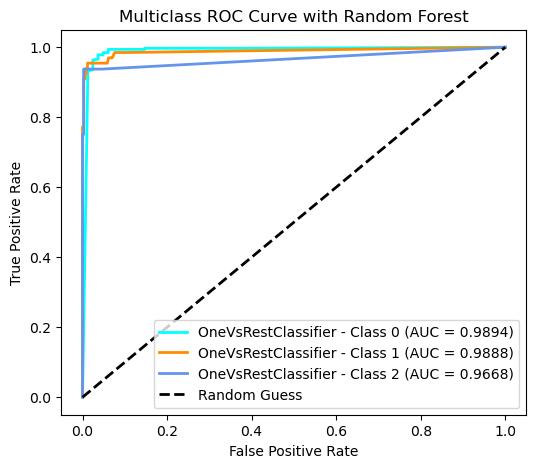

In [8]:
fpr = dict()
tpr = dict()
roc_auc = dict()

model = [rf_model]

plt.figure(figsize=(6, 5))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

for clf in model:
    for i, color in zip(range(clf.classes_.shape[0]), colors):
        fpr[i], tpr[i], _ = roc_curve(
            y_test[:, i], clf.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{clf.__class__.__name__} - Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve with Random Forest')
plt.legend(loc="lower right")
plt.show()

In [11]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("TARA_mhws_3.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)
# print(df_num.shape)
# print(df_num.columns)
# print(df_num['MHW_count'].value_counts())

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_count'] = df_numeric['mhw_count'].astype(str)

df_numeric.loc[df_numeric['mhw_count'].isin(['2', '3']), 'mhw_count'] = '2+'


print(df_numeric['mhw_count'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

shuffled_df_numeric = shuffled_df_numeric.rename({'sea surface temp': 'SST', 'sea surface quantum fluorescence': 'SSQF',
                                                  'total suspended matter': 'TSM', 'particulate inorganic carbon': 'PIC'}, axis = 1)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y = shuffled_df_numeric['mhw_count']
X.shape, y.shape

mhw_count
0     3245
1      663
2+     158
Name: count, dtype: int64


((4066, 80), (4066,))

In [15]:
# Separate features (X) and labels (y) after shuffling
X_nope = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y_nope = shuffled_df_numeric['mhw_count']

y_bin = label_binarize(y_nope, classes=np.unique(y_nope))

X_train, X_test, y_train, y_test = train_test_split(
    X_nope, y_bin, stratify = y_bin, test_size=0.3, random_state=0)

X_train.shape, y_train.shape
X_test.shape, y_test.shape

rf_model_2 = OneVsRestClassifier(
    RandomForestClassifier(class_weight = None, criterion = 'entropy', max_features = None, min_samples_split = 7, random_state=42))
rf_model_2.fit(X_train, y_train)

cross_val_scores = cross_val_score(rf_model, X_nope, y_nope, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = rf_model_2.predict(X_test)
prob_pred = rf_model_2.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print(classification_report(y_test, y_pred))

cross validation scores: [0.97297297 0.97293973 0.97416974 0.95940959 0.96432964]
0.9688 accuracy with a standard deviation of 0.0059
Accuracy: 96.89%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       974
           1       0.93      0.90      0.91       199
           2       0.92      0.98      0.95        47

   micro avg       0.97      0.97      0.97      1220
   macro avg       0.94      0.95      0.95      1220
weighted avg       0.97      0.97      0.97      1220
 samples avg       0.97      0.97      0.97      1220



C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


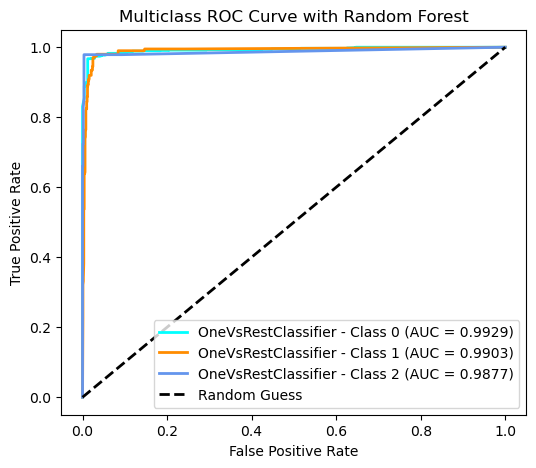

In [18]:
fpr = dict()
tpr = dict()
roc_auc = dict()

model = [rf_model_2]

plt.figure(figsize=(6, 5))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

for clf in model:
    for i, color in zip(range(clf.classes_.shape[0]), colors):
        fpr[i], tpr[i], _ = roc_curve(
            y_test[:, i], clf.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{clf.__class__.__name__} - Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve with Random Forest')
plt.legend(loc="lower right")
plt.show()

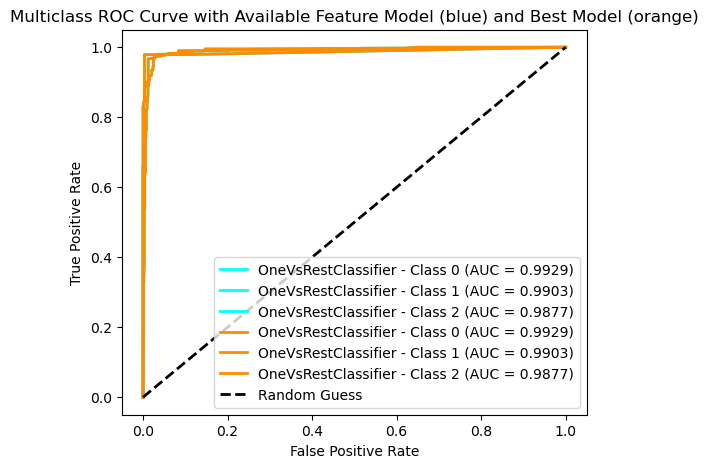

In [182]:
fpr = dict()
tpr = dict()
roc_auc = dict()

models = [rf_model_2, rf_model]

plt.figure(figsize=(6, 5))
colors = cycle(['aqua', 'darkorange'])

for model, color in zip(models, colors):
    for i in range(model.classes_.shape[0]):
        fpr[i], tpr[i], _ = roc_curve(
            y_test[:, i], model.predict_proba(X_test)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{model.__class__.__name__} - Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve with Available Feature Model (blue) and Best Model (orange)')
plt.legend(loc="lower right")
plt.show()

In [146]:
import time

feature_names = [f"feature {i}" for i in range(X.shape[1])]
start_time = time.time()
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.142 seconds


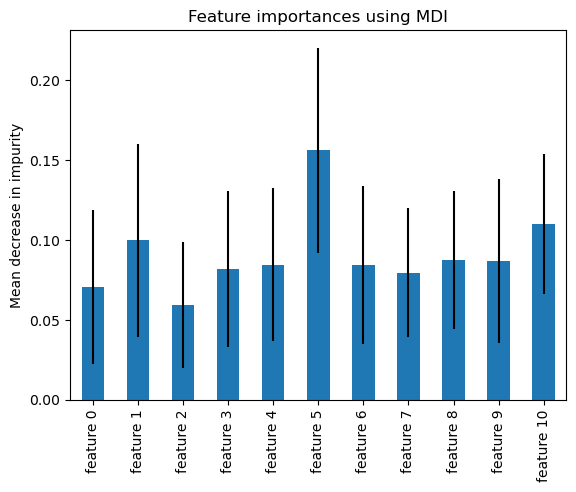

In [147]:
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
plt.show()